<a href="https://colab.research.google.com/github/shaktivel07/PINN_Fisher_KPP_Equation/blob/main/Fisher%E2%80%93KPP_Reaction%E2%80%93Diffusion_Equation_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solving the Two-Dimensional Fisher–KPP Reaction–Diffusion Equation Using Physics-Informed Neural Networks

**Date:** 22 February 2026

---

## Research Overview

**Topic:** Solving the two-dimensional Fisher–Kolmogorov–Petrovsky–Piskunov (Fisher–KPP) equation using Physics-Informed Neural Networks.

**Methodology:** The governing nonlinear reaction–diffusion partial differential equation (PDE) is solved using a Physics-Informed Neural Network (PINN) framework. The differential operator is embedded directly into the neural network loss function through automatic differentiation, eliminating the need for traditional mesh-based discretization methods such as Finite Elements or Finite Differences.

**Validation Strategy:** The spatially uniform reduction of the Fisher–KPP equation to the logistic ordinary differential equation (ODE) is used to derive an analytical closed-form solution:
$$u(t) = \frac{1}{1 + Ce^{-t}}$$
The PINN solution is validated against this analytical benchmark using relative $L^2$ error analysis and temporal profile comparison.

**Optimizer Comparison:** A convergence study is performed comparing the Adam stochastic gradient optimizer and the quasi-Newton L-BFGS algorithm. While Adam ensures rapid early-stage convergence and avoids local minima, L-BFGS refinement leverages second-order curvature information to improve residual minimization and enhance final solution accuracy.

## Problem Formulation

We consider a nonlinear two-dimensional reaction-diffusion equation of the form:

$$u_t = \alpha (u_{xx} + u_{yy}) + u(1 - u)$$

where $u(x, y, t)$ represents the scalar field of interest, $\alpha$ is the diffusion coefficient, and the nonlinear term $u(1 - u)$ models logistic growth. This class of equations arises naturally in population dynamics, thermal transport with nonlinear source terms, and pattern formation systems.

The computational domain is defined over the square region $(x, y) \in [-0.5, 0.5]$ with a time interval $t \in [0, 1]$. The initial condition is prescribed as a spatially uniform state:

$$u(x, y, 0) = 10$$

Homogeneous Neumann boundary conditions are imposed on all sides of the spatial domain, enforcing zero normal flux:

$$\nabla u \cdot \mathbf{n} = 0, \quad \text{for } (x, y) \in \partial\Omega$$

Physically, this represents an insulated or closed system in which no quantity escapes across the boundary. The governing equation is solved using a Physics-Informed Neural Network (PINN), where the differential equation and boundary constraints are embedded directly into the loss function without relying on mesh-based discretization.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Physical parameters
alpha = 0.01

# Domain
a1, b1 = -0.5, 0.5
a2, b2 = -0.5, 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Neural Network Architecture

The solution field \(u(x,y,t)\) is approximated using a fully connected feedforward neural network. The network takes the spatial and temporal coordinates \((x,y,t)\) as input and outputs a scalar prediction for the solution value. The architecture consists of three hidden layers with sixty-four neurons per layer, employing hyperbolic tangent activation functions to ensure smoothness and differentiability of higher-order derivatives.

The use of the Tanh activation function is particularly suitable for Physics-Informed Neural Networks because it is infinitely differentiable and produces stable gradients during higher-order automatic differentiation. This is essential for accurately computing second-order spatial derivatives required by the diffusion operator.

Optimization of the network parameters is performed using the Adam optimizer during the initial training phase, enabling efficient convergence in high-dimensional parameter space.

In [ ]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3,64), nn.Tanh(),
            nn.Linear(64,64), nn.Tanh(),
            nn.Linear(64,64), nn.Tanh(),
            nn.Linear(64,1)
        )

    def forward(self,x,y,t):
        return self.net(torch.cat([x,y,t],1))

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(),1e-3)

## Collocation and Constraint Sampling

The training process relies on collocation points sampled from the interior of the domain to enforce the governing partial differential equation. These points are generated using uniform random sampling across space and time, ensuring that the network learns the dynamics throughout the entire computational region.

Additional samples are generated at the initial time \(t=0\) to impose the prescribed initial condition. These points ensure that the neural network solution matches the known starting state of the system.

Boundary points are sampled along all spatial edges of the square domain. Since homogeneous Neumann conditions are imposed, the spatial derivatives normal to each boundary are computed via automatic differentiation and constrained to vanish. This guarantees zero-flux behavior and maintains physical consistency.

Although uniform random sampling is used in this implementation, more advanced strategies such as low-discrepancy Sobol sequences can further improve coverage of the domain and enhance convergence.

In [ ]:
Nf, Nic, Nbc = 15000, 2000, 2000

# Collocation points
x_f = (a1 + (b1-a1)*torch.rand(Nf,1)).to(device).requires_grad_()
y_f = (a2 + (b2-a2)*torch.rand(Nf,1)).to(device).requires_grad_()
t_f = torch.rand(Nf,1).to(device).requires_grad_()

# Initial condition
x_ic = (a1 + (b1-a1)*torch.rand(Nic,1)).to(device)
y_ic = (a2 + (b2-a2)*torch.rand(Nic,1)).to(device)
t_ic = torch.zeros_like(x_ic).to(device)
u_ic = 10*torch.ones_like(x_ic).to(device)

# Boundary points
t_bc = torch.rand(Nbc,1).to(device)

x_bc0 = a1*torch.ones(Nbc,1).to(device).requires_grad_()
x_bc1 = b1*torch.ones(Nbc,1).to(device).requires_grad_()
y_bc_x = (a2 + (b2-a2)*torch.rand(Nbc,1)).to(device)

y_bc0 = a2*torch.ones(Nbc,1).to(device).requires_grad_()
y_bc1 = b2*torch.ones(Nbc,1).to(device).requires_grad_()
x_bc_y = (a1 + (b1-a1)*torch.rand(Nbc,1)).to(device)

## Physics-Informed Optimization

The training objective consists of minimizing a composite loss function that embeds the governing equation and constraint information. The total loss is defined as the sum of the interior PDE residual loss, the initial condition loss, and the boundary condition loss.

The PDE residual is constructed by computing temporal and spatial derivatives using automatic differentiation. The residual expression:

$$\mathcal{R} = u_t - \alpha (u_{xx} + u_{yy}) - u(1 - u)$$

is evaluated at all collocation points, and its mean squared value forms the physics loss component. The initial condition loss penalizes deviations from the prescribed uniform initial state, while the boundary loss enforces the vanishing of normal derivatives (Neumann boundary conditions):

$$\nabla u \cdot \mathbf{n} = 0$$

Training is performed for several thousand epochs using gradient-based optimization. The use of automatic differentiation allows exact derivative computation without numerical discretization, eliminating truncation error typically present in finite difference or finite element methods.

In [ ]:
epochs = 5000
loss_history = []

for e in range(epochs):

    optimizer.zero_grad()

    # Resample collocation points (prevents graph reuse)
    x_f = (a1 + (b1-a1)*torch.rand(Nf,1)).to(device).requires_grad_(True)
    y_f = (a2 + (b2-a2)*torch.rand(Nf,1)).to(device).requires_grad_(True)
    t_f = torch.rand(Nf,1).to(device).requires_grad_(True)

    # Forward pass
    u = model(x_f, y_f, t_f)

    # First derivatives
    u_t = torch.autograd.grad(u, t_f, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x_f, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y_f, torch.ones_like(u), create_graph=True)[0]

    # Second derivatives
    u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_f, torch.ones_like(u_y), create_graph=True)[0]

    # PDE Residual
    res = u_t - alpha*(u_xx + u_yy) - u*(1 - u)
    loss_pde = torch.mean(res**2)

    # Initial Condition Loss
    loss_ic = torch.mean((model(x_ic, y_ic, t_ic) - u_ic)**2)

    # Boundary Condition (Resample each epoch safely)

    # x-boundaries
    x_bc0 = a1*torch.ones(Nbc,1).to(device).requires_grad_(True)
    x_bc1 = b1*torch.ones(Nbc,1).to(device).requires_grad_(True)
    y_bc_x = (a2 + (b2-a2)*torch.rand(Nbc,1)).to(device)
    t_bc = torch.rand(Nbc,1).to(device)

    u0 = model(x_bc0, y_bc_x, t_bc)
    u1 = model(x_bc1, y_bc_x, t_bc)

    ux0 = torch.autograd.grad(u0, x_bc0, torch.ones_like(u0), create_graph=True)[0]
    ux1 = torch.autograd.grad(u1, x_bc1, torch.ones_like(u1), create_graph=True)[0]

    # y-boundaries
    y_bc0 = a2*torch.ones(Nbc,1).to(device).requires_grad_(True)
    y_bc1 = b2*torch.ones(Nbc,1).to(device).requires_grad_(True)
    x_bc_y = (a1 + (b1-a1)*torch.rand(Nbc,1)).to(device)

    v0 = model(x_bc_y, y_bc0, t_bc)
    v1 = model(x_bc_y, y_bc1, t_bc)

    uy0 = torch.autograd.grad(v0, y_bc0, torch.ones_like(v0), create_graph=True)[0]
    uy1 = torch.autograd.grad(v1, y_bc1, torch.ones_like(v1), create_graph=True)[0]

    loss_bc = torch.mean(ux0**2) + torch.mean(ux1**2) + \
              torch.mean(uy0**2) + torch.mean(uy1**2)

    # Total Loss
    loss = loss_pde + loss_ic + loss_bc

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if e % 500 == 0:
        print(f"Epoch {e} | Loss: {loss.item():.6f}")

Epoch 0 | Loss: 99.001663
Epoch 500 | Loss: 0.046084
Epoch 1000 | Loss: 0.008747
Epoch 1500 | Loss: 0.003677
Epoch 2000 | Loss: 0.001988
Epoch 2500 | Loss: 0.000860
Epoch 3000 | Loss: 0.000724
Epoch 3500 | Loss: 0.000349
Epoch 4000 | Loss: 0.000417
Epoch 4500 | Loss: 0.000857


## Logistic Reduction and Exact Solution

If the solution remains spatially uniform, the diffusion terms vanish and the governing partial differential equation reduces to the ordinary differential equation:

$$\frac{du}{dt} = u(1 - u)$$

This logistic equation admits the analytical solution:

$$u(t) = \frac{1}{1 + Ce^{-t}}$$

where the constant $C$ is determined by the initial condition. For the specific case where $u(0) = 10$, the constant evaluates to $C = -0.9$ (or $C = -\frac{9}{10}$). This closed-form solution provides a critical reference benchmark against which the Physics-Informed Neural Network (PINN) prediction can be validated.

The presence of an exact solution is particularly valuable in assessing the convergence accuracy, numerical stability, and overall correctness of the PINN implementation.

In [ ]:
def exact_solution(t):
    C = -9/10
    return 1/(1 + C*torch.exp(-t))

## Temporal Validation at the Domain Center

To assess the accuracy of the trained model, the solution is evaluated at the spatial center of the domain \((x,y)=(0,0)\) across the time interval. Since the analytical solution derived from logistic reduction is spatially uniform, the predicted value at the center should coincide with the exact temporal evolution.

The relative \(L^2\) error is computed to quantify agreement between the neural network solution and the analytical reference. A small relative error confirms that the network has successfully captured both the nonlinear reaction dynamics and the governing differential structure.

Relative L2 Error: 0.001336588873527944


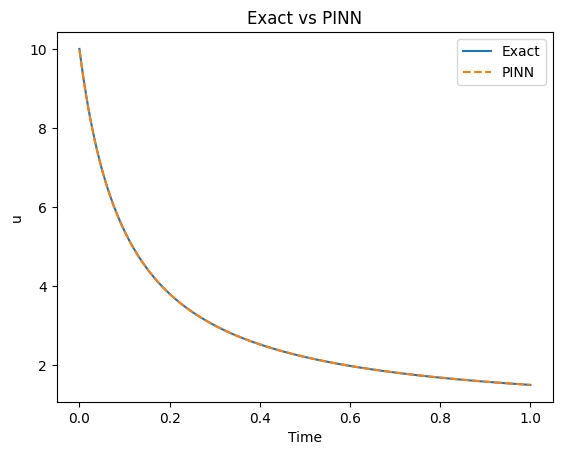

In [ ]:
t_test = torch.linspace(0,1,200).reshape(-1,1).to(device)
x_test = torch.zeros_like(t_test).to(device)
y_test = torch.zeros_like(t_test).to(device)

with torch.no_grad():
    u_pinn = model(x_test,y_test,t_test)

u_exact = exact_solution(t_test)

rel_error = torch.norm(u_pinn - u_exact)/torch.norm(u_exact)
print("Relative L2 Error:", rel_error.item())

plt.plot(t_test.cpu(),u_exact.cpu(),label="Exact")
plt.plot(t_test.cpu(),u_pinn.cpu(),'--',label="PINN")
plt.legend()
plt.xlabel("Time")
plt.ylabel("u")
plt.title("Exact vs PINN")
plt.show()

## Heatmap Visualization and Error Distribution

A spatial snapshot at a fixed time is used to analyze the quality of the learned solution across the domain. The predicted field, exact field, and absolute error are visualized using heatmaps.

Since the analytical solution is spatially uniform, the predicted field should exhibit near-constant values throughout the domain. Any deviation from uniformity indicates numerical artifacts or insufficient enforcement of boundary conditions.

Visualization of the absolute error provides insight into spatial bias, boundary inconsistencies, or localized instability. Heatmap analysis is essential for diagnosing potential weaknesses in the PINN approximation.

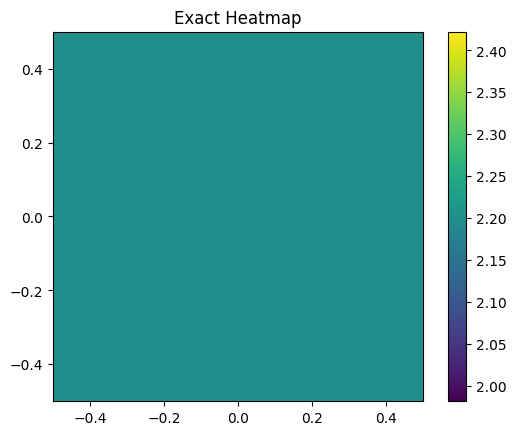

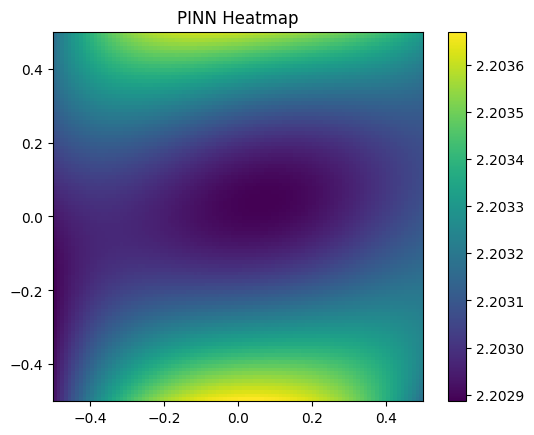

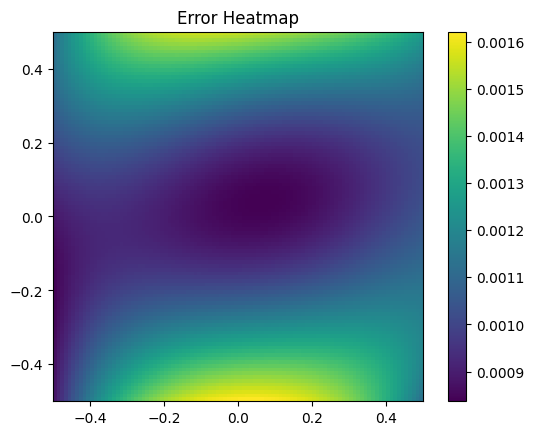

In [ ]:
x = torch.linspace(a1,b1,100)
y = torch.linspace(a2,b2,100)
X,Y = torch.meshgrid(x,y,indexing='ij')
T = 0.5*torch.ones_like(X)

with torch.no_grad():
    U_pred = model(X.reshape(-1,1).to(device),
                   Y.reshape(-1,1).to(device),
                   T.reshape(-1,1).to(device))

U_pred = U_pred.reshape(100,100).cpu()

u_exact_val = exact_solution(torch.tensor(0.5))
U_exact = u_exact_val*torch.ones_like(U_pred)

error_map = torch.abs(U_pred - U_exact)

plt.imshow(U_exact,extent=[a1,b1,a2,b2],origin='lower')
plt.title("Exact Heatmap")
plt.colorbar()
plt.show()

plt.imshow(U_pred,extent=[a1,b1,a2,b2],origin='lower')
plt.title("PINN Heatmap")
plt.colorbar()
plt.show()

plt.imshow(error_map,extent=[a1,b1,a2,b2],origin='lower')
plt.title("Error Heatmap")
plt.colorbar()
plt.show()

## Optimizer Comparison: Adam versus L-BFGS Refinement

After initial convergence using the Adam optimizer, a second optimization stage is performed using the Limited-memory Broyden–Fletcher–Goldfarb–Shanno (L-BFGS) algorithm. While Adam provides efficient stochastic gradient-based updates and ensures rapid early-stage convergence, L-BFGS leverages quasi-Newton curvature approximations to refine the solution in the neighborhood of a minimum.

In this implementation, the full composite physics loss consisting of the PDE residual and initial condition constraint is minimized during the L-BFGS phase. Fresh collocation points are sampled inside the closure function to prevent computational graph reuse and to ensure stable second-order optimization.

The relative \(L^2\) error is evaluated before and after L-BFGS refinement to quantify performance improvement. A visual comparison of the temporal evolution predicted by Adam and L-BFGS against the analytical solution is provided to assess convergence sharpness and solution fidelity.

Relative Error after Adam: 0.001336588873527944
L-BFGS optimization complete.
Relative Error after L-BFGS: 0.00011240656021982431
Improvement in Relative Error: 0.0012241823133081198


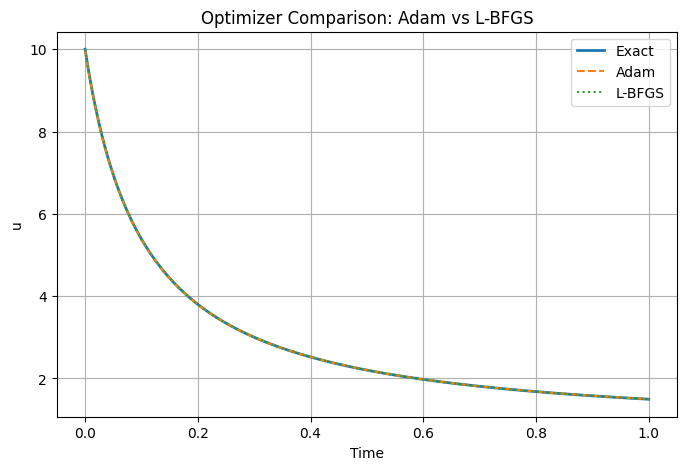

In [ ]:
# Evaluate after Adam training
with torch.no_grad():
    u_adam = model(x_test, y_test, t_test)

rel_error_adam = torch.norm(u_adam - u_exact) / torch.norm(u_exact)
print("Relative Error after Adam:", rel_error_adam.item())

# L-BFGS Optimizer Definition
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=500,
    tolerance_grad=1e-9,
    tolerance_change=1e-9
)

def closure():
    optimizer_lbfgs.zero_grad()

    # Fresh collocation points (prevents graph reuse)
    x_f = (a1 + (b1-a1)*torch.rand(Nf,1)).to(device).requires_grad_(True)
    y_f = (a2 + (b2-a2)*torch.rand(Nf,1)).to(device).requires_grad_(True)
    t_f = torch.rand(Nf,1).to(device).requires_grad_(True)

    u = model(x_f,y_f,t_f)

    # First derivatives
    u_t = torch.autograd.grad(u,t_f,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,x_f,torch.ones_like(u),create_graph=True)[0]
    u_y = torch.autograd.grad(u,y_f,torch.ones_like(u),create_graph=True)[0]

    # Second derivatives
    u_xx = torch.autograd.grad(u_x,x_f,torch.ones_like(u_x),create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y,y_f,torch.ones_like(u_y),create_graph=True)[0]

    # PDE residual
    res = u_t - alpha*(u_xx+u_yy) - u*(1-u)
    loss_pde = torch.mean(res**2)

    # Initial condition loss
    loss_ic = torch.mean((model(x_ic,y_ic,t_ic)-u_ic)**2)

    loss = loss_pde + loss_ic
    loss.backward()
    return loss

# Run L-BFGS
optimizer_lbfgs.step(closure)
print("L-BFGS optimization complete.")

# Evaluate after L-BFGS
with torch.no_grad():
    u_lbfgs = model(x_test, y_test, t_test)

rel_error_lbfgs = torch.norm(u_lbfgs - u_exact) / torch.norm(u_exact)
print("Relative Error after L-BFGS:", rel_error_lbfgs.item())

# Improvement Calculation
improvement = rel_error_adam - rel_error_lbfgs
print("Improvement in Relative Error:", improvement.item())

# Visual Comparison
plt.figure(figsize=(8,5))
plt.plot(t_test.cpu(), u_exact.cpu(), label="Exact", linewidth=2)
plt.plot(t_test.cpu(), u_adam.cpu(), '--', label="Adam")
plt.plot(t_test.cpu(), u_lbfgs.cpu(), ':', label="L-BFGS")
plt.legend()
plt.title("Optimizer Comparison: Adam vs L-BFGS")
plt.xlabel("Time")
plt.ylabel("u")
plt.grid(True)
plt.show()

---

## Internship Acknowledgment and Repository Information

This project was developed as part of my research internship at the National Institute of Technology, Tiruchirappalli, under the Department of Mathematics. The work focuses on the implementation and analysis of a Physics-Informed Neural Network (PINN) for solving the nonlinear Fisher–KPP reaction–diffusion equation, integrating analytical validation, optimizer comparison, and spatial error analysis within a unified computational framework.

A complete discussion of the methodology, experimental setup, implementation details, numerical observations, and extended analysis can be found in the official GitHub repository:

https://github.com/shaktivel07/PINN_Fisher_KPP_Equation

For any clarifications, implementation-related issues, or research discussions, feel free to contact:

shaktivelkumaresan07@gmail.com

---